In [1]:
#The script collects regridded files saved in scratch, calculates extreme precipitation days using 

#00. libraries and dask client 
import time
import xarray as xr
import numpy as np
import glob
import datetime
import time
import pandas as pd

import os
import gc

import matplotlib
import xarray, matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import cartopy
import cartopy.crs as ccrs
# import matplotlib.pyplot as plt
import cartopy.feature as cfeature
# from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm
import matplotlib as mpl


import dask #parralelle processing 
import subprocess
import dask.array as da
from memory_profiler import profile
from filelock import FileLock
from dask.distributed import Client
from dask.utils import SerializableLock

# # Define a global or top-level lock (to reuse across function calls if needed)
# netcdf_write_lock = SerializableLock()


from dask.diagnostics import ProgressBar

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34371,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38177,Total threads: 1
Dashboard: /proxy/44353/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:33705,


In [3]:
#1.0 load data and classify exceedance define functions --by fixed thresholds 28/32/35
#removed tempRes from standard fuction 
def load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR,tempRes, idir):
    path_mask = (
        f"{IDIR}{var}_{domain}_{GCM}_{sc}_{meG}_{provider}_{RCM}_{meR}_{tempRes}*.nc"
    )
    files = glob.glob(path_mask)

    def sanitize(ds):
        return ds.drop_dims('crs') if 'crs' in ds.dims else ds

    with dask.config.set(**{'array.slicing.split_large_chunks': False}):
        ds = xr.open_mfdataset(files, preprocess=sanitize, combine='by_coords')
    
    return ds.chunk(chunks={'time':365, 'lat': 'auto', 'lon': 'auto'})

def determine_univariate_fixed(data, out_prefix, thresh=28, ttype='f+'):
    # Same logic...
    if 'q' in ttype:
        threshold = data.quantile(thresh, 'time')
    else:
        threshold = thresh
    
    # threshold = threshold.chunk(data.chunks)#fix
    # threshold = threshold.compute()#fix
    
    univ_exceed = xr.where(data > threshold, 1, 0) if '+' in ttype else xr.where(data < threshold, 1, 0)
    univ_exceed = univ_exceed.chunk({'time': 50})  # or 100, or 'auto' — tune as needed
    
    out_file = f"{out_prefix}_univ_exceed_{thresh}.nc"
    # threshold_out_file = f"{out_prefix}_threshold.nc"
    
    
    # Clean up old files first--fix
    for f in [out_file]:#, threshold_out_file]:
        if os.path.exists(f):
            os.remove(f)
    
    univ_exceed = univ_exceed.chunk({'time': 50})  # or 100, or 'auto' — tune as needed

    with FileLock(f"{out_file}.lock"):
        univ_exceed.to_netcdf(out_file)
    # with FileLock(f"{threshold_out_file}.lock"):
    #     threshold.to_netcdf(threshold_out_file)
    
    del univ_exceed, threshold, data
    gc.collect()



In [5]:
#1.1.1-28 iteration
GCMs =['ACCESS-ESM1-5']  
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['ssp126','ssp245','historical', 'ssp370']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r6i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=28, ttype='f+')#modified 
               



In [ ]:
#1.1.1-32 iteration
GCMs =['ACCESS-ESM1-5']  
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['ssp126','ssp245','historical', 'ssp370']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r6i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=32, ttype='f+')#modified 
               


In [ ]:
#1.1.1-35 iteration
GCMs =['ACCESS-ESM1-5']  
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['ssp126','ssp245','historical', 'ssp370']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r6i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=35, ttype='f+')#modified 
               


In [5]:
#1.1.2 --28 iteration --EC-Earth3-Veg 
GCMs =['EC-Earth3-Veg']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe
                
                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=28, ttype='f+')#modified 
               
               


In [ ]:
#1.1.2 --32 iteration --EC-Earth3-Veg 
GCMs =['EC-Earth3-Veg']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe
                
                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=32, ttype='f+')#modified 
               
               


In [ ]:
#1.1.2 --35 iteration --EC-Earth3-Veg 
GCMs =['EC-Earth3-Veg']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe
                
                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=35, ttype='f+')#modified 
               
               


In [8]:
#1.1.3--28 iteration --MPI
GCMs =['MPI-ESM1-2-HR']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=28, ttype='f+')#modified 
               


In [ ]:
#1.1.3--32 iteration --MPI
GCMs =['MPI-ESM1-2-HR']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=32, ttype='f+')#modified 
               


In [ ]:
#1.1.3--35 iteration --MPI
GCMs =['MPI-ESM1-2-HR']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=35, ttype='f+')#modified 
               


In [5]:
#1.1.4 --28 iteration 
GCMs =['NorESM2-MM']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=28, ttype='f+')#modified 



In [ ]:
#1.1.4--32 iteration 
GCMs =['NorESM2-MM']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=32, ttype='f+')#modified 



In [ ]:
#1.1.4--35 iteration 
GCMs =['NorESM2-MM']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f1'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=35, ttype='f+')#modified 



In [8]:
#1.1.5--28 iteration
GCMs =['UKESM1-0-LL']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f2'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=28, ttype='f+')#modified



In [ ]:
#1.1.5--32 iteration
GCMs =['UKESM1-0-LL']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f2'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=32, ttype='f+')#modified



In [ ]:
#1.1.5--35 iteration
GCMs =['UKESM1-0-LL']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                meG = 'r1i1p1f2'
                meR = 'v1-r1'
                domain = 'AUS-18'
                provider = 'NSW-Government'
                tempRes = 'day'
                IDIR = '/scratch/dt6/xw9650/tmp/derived/'
                OUTDIR = '/scratch/dt6/xw9650/tmp/'
                
                data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                data = data.persist()  # ✅ More memory-safe

                prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
                determine_univariate_fixed(data, prefix, thresh=35, ttype='f+')#modified



In [2]:
#2. select city gridcells and subset exceedance data
#define gridcells and prepare into dataframe
city_gridcells = {
    "Sydney": [
        (-33.7, 150.7),
        (-33.7, 150.9),
        (-33.7, 151.1),
        (-33.7, 151.3),
        (-33.9, 150.7),        
        (-33.9, 150.9),
        (-33.9, 151.1),
        (-34.1, 150.7),
    ],

    "Brisbane": [
        (-27.3, 152.9),
        (-27.3, 153.1),
        (-27.5, 152.9),
        (-27.5, 153.1),
        (-27.7, 152.9),
        (-27.7, 153.1),
        (-27.7, 153.3),
        (-27.9, 153.3),
    ],

    "Melbourne": [
        (-37.7, 144.7),
        (-37.7, 144.9),
        (-37.7, 145.1),
        (-37.9, 144.7),
        (-37.9, 145.1),
        (-37.9, 145.3),
        (-38.1, 145.3),
        (-38.3, 145.1),
    ],

    "Perth": [
        (-31.9, 115.9),
        (-32.1, 115.9),
        (-32.3, 115.9),
        (-32.5, 115.9),
        (-32.7, 115.9),
        (-32.9, 115.9),
        (-33.1, 115.9),
        (-33.3, 115.7),
    ],
    "Darwin": [
        (-12.5, 130.9),
        (-12.5, 131.1),
    ],
}
records = []
for city, points in city_gridcells.items():
    for i, (lat, lon) in enumerate(points):
        records.append({
            "city": city,
            "point_id": f"{city}_{i+1}",
            "lat": lat,
            "lon": lon
        })
df_points = pd.DataFrame(records)

#function variables
INDIR='/scratch/dt6/xw9650/tmp/'
out_folder = "/scratch/dt6/xw9650/tmp/city_subsets"
os.makedirs(out_folder, exist_ok=True)

GCMs =['ACCESS-ESM1-5','EC-Earth3-Veg','MPI-ESM1-2-HR','NorESM2-MM','UKESM1-0-LL']  # ,,  Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
scenarios = ['historical', 'ssp370','ssp126','ssp245']
vars = ['wbgt']
thresholds=['28','32','35']

#create city subsets for selected dataset

for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            for sc in scenarios:
                for thresh in thresholds:
                    prefix = f"{INDIR}{var}_{GCM}_{RCM}_{sc}"
                    ds=xr.open_dataset(f"{prefix}_univ_exceed_{thresh}.nc")

                    subset = ds.sel(
                        lat=xr.DataArray(df_points["lat"], dims="point"),
                        lon=xr.DataArray(df_points["lon"], dims="point"),
                        method="nearest"
                    )
                    subset = subset.assign_coords(
                        city=("point", df_points["city"].values),
                        point_id=("point", df_points["point_id"].values),
                        lat=("point", df_points["lat"].values),
                        lon=("point", df_points["lon"].values),
                    )

    
                    # Save all cities 
                    out_file = os.path.join(
                        out_folder,
                        f"{var}_{GCM}_{RCM}_{sc}_{thresh}.nc"
                    )
                    subset.to_netcdf(out_file)
                    print(f"Saved {city} subset to {out_file}")
                     


Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_historical_28.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_historical_32.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_historical_35.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_28.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_32.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_35.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp126_28.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp126_32.nc
Saved Darwin subset to /scratch/dt6/xw9650/tmp/city_subsets/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp126_35.nc
Saved D

In [2]:
#3.0 annual summary 
def summarize_annual_city_subset_data_to_netcdf(dataset_path_hist, dataset_path_future, variable_name,
                                               start_year, end_year, summaries_file):
    # file_path1=dataset_path_hist
    # lock=FileLock(f"{file_path1}.lock")
    # with lock: 
    #     ds1 = xr.open_dataset(dataset_path_hist, chunks={'time': -1, 'lat': 24, 'lon': 24}, lock=False)
    
    # file_path2=dataset_path_future
    # lock=FileLock(f"{file_path2}.lock")
    # with lock: 
    #     ds2 = xr.open_dataset(dataset_path_future, chunks={'time': -1, 'lat': 24, 'lon': 24}, lock=False)
    
        
    ds1 = xr.open_dataset(dataset_path_hist, chunks={'time': -1, 'point':32}, lock=False)
    ds2 = xr.open_dataset(dataset_path_future, chunks={'time': -1,'point':32}, lock=False)
    ds = xr.concat([ds1, ds2], dim='time')
 

    # Use .dt accessor safely for cftime or datetime
    if not np.issubdtype(ds['time'].dtype, np.datetime64):
        time_years = ds['time'].dt.year.values
    else:
        ds['time'] = pd.to_datetime(ds['time'].values)
        time_years = ds['time'].dt.year.values

    summaries, deltas = [], []
    for year in range(start_year, end_year + 1):
         # Select time using year mask, safe for non-Gregorian calendars
        year_data = ds.where(ds['time'].dt.year == year, drop=True)

        if year_data.time.size == 0:
            print(f"⚠️ No data for year {year}, skipping.")
            continue
        year_summary = year_data[variable_name].sum(dim='time')  # Keep spatial dims
        summaries.append(year_summary)

        if len(summaries) > 1:
            deltas.append(year_summary - summaries[-2])

    summaries_da = xr.concat(summaries, dim='year')
    summaries_da['year'] = pd.to_datetime([f'{y}-01-01' for y in range(start_year, end_year + 1)])
    summaries_da.to_netcdf(summaries_file)


In [3]:
# 3.1 ==== Configurable section ====
gcms = ['ACCESS-ESM1-5','EC-Earth3-Veg','MPI-ESM1-2-HR','NorESM2-MM','UKESM1-0-LL']
rcms =  ['NARCliM2-0-WRF412R3','NARCliM2-0-WRF412R5']
variables = ['wbgt']
scenarios = ['ssp370','ssp245','ssp126']
threshold=['28','32','35']

base_dir = '/scratch/dt6/xw9650/tmp/city_subsets/'
output_dir = '/scratch/dt6/xw9650/tmp/city_subsets_annual/'
start_year = 1951
end_year = 2100

for gcm in gcms:
    for rcm in rcms:
        for var in variables:
            for scen in scenarios:
                for thresh in threshold:
                    model_id = f"{var}_{gcm}_{rcm}_{scen}_{thresh}"
                    hist_file = f"{base_dir}{var}_{gcm}_{rcm}_historical_{thresh}.nc"
                    fut_file = f"{base_dir}{var}_{gcm}_{rcm}_{scen}_{thresh}.nc"
                    summary_file = f"{output_dir}{model_id}_annual_summary.nc"
                    # delta_file = f"{base_dir}{model_id}_annual_delta.nc"
    
                    print(f"\n🔄 Processing {model_id}...")
    
                    try:
                        summarize_annual_city_subset_data_to_netcdf(
                            dataset_path_hist=hist_file,
                            dataset_path_future=fut_file,
                            variable_name=var,
                            start_year=start_year,
                            end_year=end_year,
                            summaries_file=summary_file
                            
                        )
    
                        # plot_annual_exceedance_bar(
                        #     summary_file=summary_file,
                        #     output_folder=output_plot_dir,
                        #     model_id=model_id
                        # )
    
                    except Exception as e:
                        print(f"❌ Error processing {model_id}: {e}")



🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_28...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_32...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_35...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_28...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_32...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_35...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp126_28...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp126_32...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp126_35...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_28...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_32...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_35...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp245_28...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp245_32...

🔄 Processing wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp245_35...

🔄 Process

In [6]:
#3.2 combined annual summary for all ensembles, scenarios and thresholds 
import os
import glob
import xarray as xr
import numpy as np
import dask
import re
import matplotlib.pyplot as plt

# ------------------------------------------
# USER CONFIG
# ------------------------------------------
data_dir = "/scratch/dt6/xw9650/tmp/city_subsets_annual/"
scenarios = ["ssp126", "ssp245", "ssp370"]
thresholds = ["28", "32", "35"]

# Example city to plot--this is not used yet
# city = "Sydney"

# ------------------------------------------
# FILE PARSER FOR METADATA
# ------------------------------------------

def parse_filename(fname):
    base = os.path.basename(fname)
    m = re.match(
        r"wbgt_(.+)_(NARCliM2-0-.+?)_(ssp\d\d\d)_(\d+)_annual_summary.nc",
        base
    )
    if not m:
        raise ValueError(f"Filename format not recognized: {base}")
    
    gcm = m.group(1)
    rcm = m.group(2)
    scenario = m.group(3)
    threshold = m.group(4)
    return gcm, rcm, scenario, threshold


# ------------------------------------------
# LOAD AND COMBINE ALL FILES
# ------------------------------------------

def load_and_combine(data_dir):
    pattern = os.path.join(data_dir, "wbgt_*_annual_summary.nc")
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} files")
    
    # Lists to store datasets and their metadata
    datasets = []
    
    for f in files:
        gcm, rcm, scenario, threshold = parse_filename(f)
        ensemble = f"{gcm}_{rcm}"
        
        # Open the dataset
        ds = xr.open_dataset(f)
        
        # Add metadata as coordinates (scalar coordinates for this file)
        ds = ds.assign_coords({
            'gcm': gcm,
            'rcm': rcm,
            'scenario': scenario,
            'threshold': threshold,
            'ensemble': ensemble
        })
        
        # Expand dimensions to include ensemble dimension
        # This creates a new dimension for this ensemble
        ds_expanded = ds.expand_dims({
            'ensemble': [ensemble],
            'scenario': [scenario],
            'threshold': [threshold]
        })
        
        datasets.append(ds_expanded)
    
    # Combine all datasets along the ensemble dimension
    # combined = xr.concat(datasets, dim='ensemble')#, coords='minimal')
    combined=xr.combine_by_coords(datasets)

    
    # The combined dataset now has dimensions: (ensemble, year, point)
    # But we might want to reorganize for easier plotting
    return combined


# ------------------------------------------
# LOAD DATA
# ------------------------------------------

with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ds_combined = load_and_combine(data_dir)


#checks
# print("Combined dataset structure:")
# print(ds_combined)
# print(f"\nDimensions: {ds_combined.dims}")
# print(f"\nEnsembles: {len(ds_combined.ensemble)}")
# print(f"\nEnsembles: {np.unique(ds_combined.ensemble.values)}")

# print(f"\nScenarios: {len(ds_combined.scenario)}")
# print(f"\nScenarios: {np.unique(ds_combined.scenario.values)}")
# print(f"\nThresholds: {np.unique(ds_combined.threshold.values)}")
# print(f"\nCities available: {np.unique(ds_combined.city.values)}")

# ens_df = ds_combined[['ensemble','gcm','rcm','scenario','threshold']].to_dataframe().reset_index()
# print(ens_df)

output_file = "/scratch/dt6/xw9650/tmp/city_subsets_annual/wbgt_combined_annual_summary.nc"  # change path as needed
ds_combined.to_netcdf(output_file)
print(f"Combined dataset saved to {output_file}")



Found 90 files


/jobfs/160135164.gadi-pbs/ipykernel_2052763/4142561171.py:80: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  combined=xr.combine_by_coords(datasets)
/jobfs/160135164.gadi-pbs/ipykernel_2052763/4142561171.py:80: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  combined=xr.combine_by_coords(datasets)
/jobfs/160135164.g

Combined dataset saved to /scratch/dt6/xw9650/tmp/city_subsets_annual/wbgt_combined_annual_summary.nc


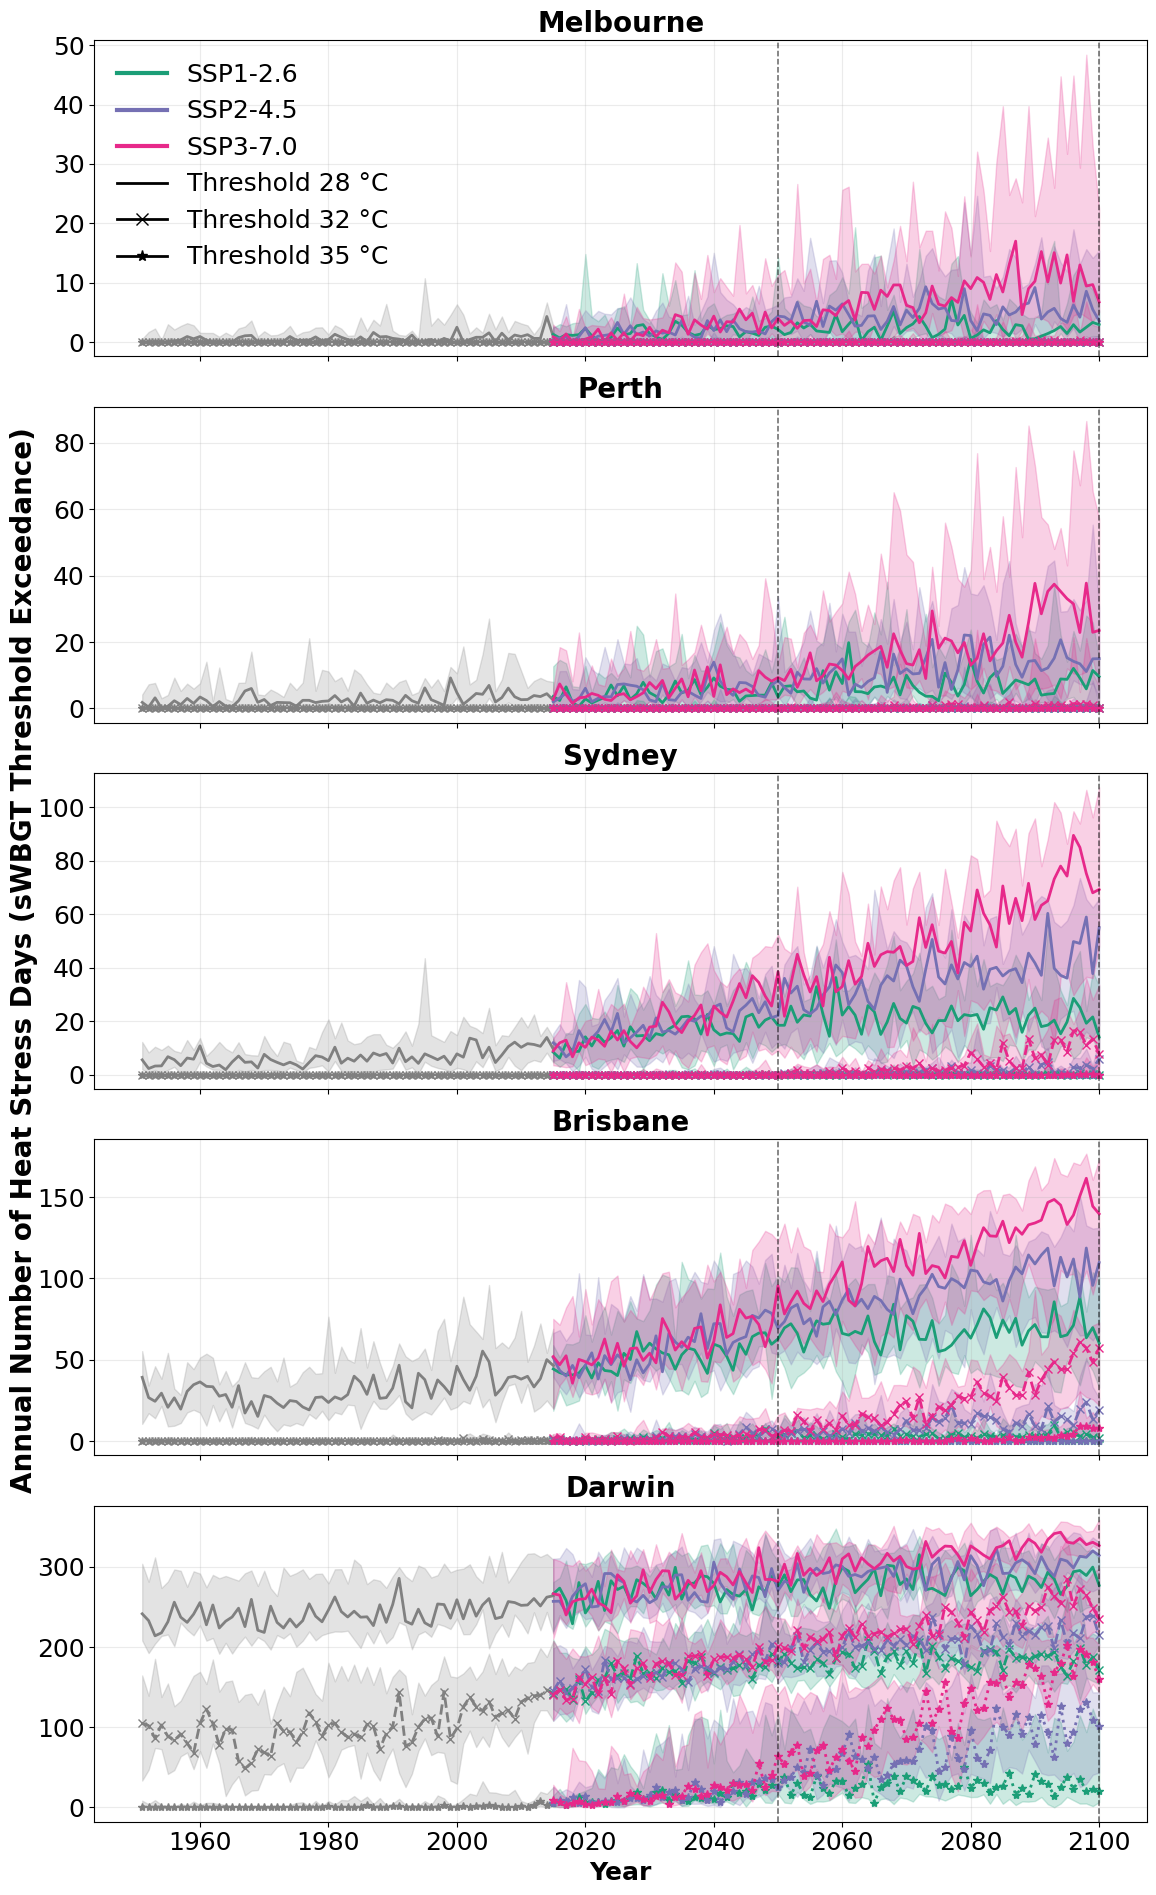

In [2]:
#3.4 plot annual heat stress for different threshold and different scenarios by city 
#5 cities (used in paper) 
#plot dimensions designed for five cities 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# load dataset
ds = xr.open_dataset("/scratch/dt6/xw9650/tmp/city_subsets_annual/wbgt_combined_annual_summary.nc")

def plot_cities_legend_top_left(
    ds,
    cities,
    thresholds=['28','32','35'],
    scenarios=['ssp126','ssp245','ssp370'],
    cut_year=2015,
    show_marks=(2050,2100),
    ipcc_colors=None,
    figsize=(12,4),
    markers=None,
    fontsize_title=20,   # <- increase title font
    fontsize_ylabel=20,  # <- increase y-axis font
    fontsize_legend=18,   # <- increase legend font
    fontsize_xlabel=18,  # <- increase y-axis font
    fontsize_ticks=18,   # axis tick label font
    # figure_title="Rising Heat Stress Days with Potential Human Health Implications",
    figure_title='',
    fontsize_suptitle=20
    
):
    if ipcc_colors is None:
        ipcc_colors = {'ssp126':'#1b9e77','ssp245':'#7570b3','ssp370':'#e7298a','ssp585':'#d95f02'}
    if markers is None:
        markers = {'32':'x','35':'*','28':None}
    linestyles = {'28':'-','32':'--','35':':'}

    n_cities = len(cities)
    fig, axes = plt.subplots(nrows=n_cities, ncols=1,
                             figsize=(figsize[0], figsize[1]*n_cities),
                             sharex=True)
    fig.suptitle(
        figure_title,
        fontsize=fontsize_suptitle,
        fontweight='bold',
        x=0.5,      # <-- force horizontal center
        ha='center',
        y=0.98      # adjust vertical spacing
    )

    if n_cities == 1: axes = [axes]

    years = ds.year.dt.year.values
    mask_hist = years <= cut_year
    mask_fut  = years >= cut_year

    for ax, city in zip(axes, cities):
        ds_city = ds.sel(point=ds.city==city).mean('point')

        for thr in thresholds:
            da = ds_city.wbgt.sel(threshold=thr)

            # --- historical (<cut_year) grey line only ---
            if mask_hist.any():
                hist_da = da.sel(year=ds.year[mask_hist])
                # hist_mean = hist_da.mean(['ensemble','scenario'])
                hist_mean = hist_da.median(['ensemble','scenario']) #modified to median
                hist_lo = hist_da.quantile(0.1, dim=['ensemble','scenario'])
                hist_hi = hist_da.quantile(0.9, dim=['ensemble','scenario'])

                # shaded band
                ax.fill_between(years[mask_hist], hist_lo.values, hist_hi.values,
                                color='grey', alpha=0.22)

                # mean line with marker
                ax.plot(years[mask_hist], hist_mean.values,
                        color='grey',
                        linestyle=linestyles.get(thr,'-'),
                        marker=markers.get(thr,None),
                        markersize=6,
                        linewidth=2)

            # --- future (>=cut_year) scenario colored lines + shading ---
            if mask_fut.any():
                for sc in scenarios:
                    fut = da.sel(scenario=sc, year=ds.year[mask_fut])
                    # mean = fut.mean('ensemble')
                    mean = fut.median('ensemble')
                    lo = fut.quantile(0.1, dim='ensemble')
                    hi = fut.quantile(0.9, dim='ensemble')

                    # shading
                    ax.fill_between(years[mask_fut], lo.values, hi.values,
                                    color=ipcc_colors[sc], alpha=0.22)
                    # line
                    ax.plot(
                        years[mask_fut], mean.values,
                        color=ipcc_colors[sc],
                        linestyle=linestyles.get(thr,'-'),
                        marker=markers.get(thr,None),
                        markersize=6,
                        linewidth=2
                    )

        # vertical markers (no label)
        for yr in show_marks:
            if years.min() <= yr <= years.max():
                ax.axvline(yr, color='black', ls='--', lw=1.1, alpha=0.6)

        # subplot title with larger font
        ax.set_title(f"{city}", fontsize=fontsize_title, fontweight='bold')
        ax.grid(alpha=0.25)
        # ax.set_ylim(0, 175)  # fixed y-axis range

    # remove individual ylabels
    for ax in axes:
        ax.set_ylabel("")
        # set tick label size for both axes explicitly
        ax.tick_params(axis='x', labelsize=fontsize_ticks)
        ax.tick_params(axis='y', labelsize=fontsize_ticks)

    # add a single y-label for the whole figure
    fig.text(0.04, 0.5, "Annual Number of Heat Stress Days (sWBGT Threshold Exceedance)", va='center', rotation='vertical',
             fontsize=fontsize_ylabel, fontweight='bold')

    # x-axis label only for bottom subplot
    axes[-1].set_xlabel("Year", fontsize=fontsize_xlabel,fontweight='bold')

    # --- Create legend on top-left of first axis only ---
    top_ax = axes[0]
    # Map scenarios to desired legend labels
    scenario_labels_map = {
        'ssp126': 'SSP1-2.6',
        'ssp245': 'SSP2-4.5',
        'ssp370': 'SSP3-7.0'
    }
    # Map thresholds to desired legend labels
    threshold_labels_map = {
        '28': 'Threshold 28 °C',
        '32': 'Threshold 32 °C',
        '35': 'Threshold 35 °C'
    }
    scenario_handles = [Line2D([0],[0], color=ipcc_colors[sc], lw=3) for sc in scenarios]
    scenario_labels  = [scenario_labels_map[sc] for sc in scenarios]


    threshold_handles = [Line2D([0],[0], color='black', lw=2,
                                 marker=markers[thr], linestyle='-', markersize=8)
                         for thr in thresholds]
    threshold_labels = [threshold_labels_map[thr] for thr in thresholds]

    handles = scenario_handles + threshold_handles
    labels = scenario_labels + threshold_labels

    top_ax.legend(handles, labels, loc='upper left', frameon=False, fontsize=fontsize_legend)

    plt.tight_layout(rect=[0.05,0.03,1,0.99])  # leave space for shared ylabel

    # save figure
    out_dir = '/scratch/dt6/xw9650/tmp/city_subsets_annual/'
    fig.savefig(f"{out_dir}city_wbgt_exceedance_trends.png", dpi=300, bbox_inches='tight')

# --- call the function ---
cities = [ 'Melbourne', 'Perth', 'Sydney','Brisbane','Darwin']
plot_cities_legend_top_left(ds, cities=cities, thresholds=['28','32','35'])


In [13]:
gcms = ['ACCESS-ESM1-5','EC-Earth3-Veg','MPI-ESM1-2-HR','NorESM2-MM','UKESM1-0-LL']
rcms =  ['NARCliM2-0-WRF412R3','NARCliM2-0-WRF412R5']
variables = ['wbgt']
scenarios = ['ssp370','ssp245','ssp126']
threshold=['28','32','35']

base_dir = '/scratch/dt6/xw9650/tmp/city_subsets/'
outdir = '/scratch/dt6/xw9650/tmp/city_subsets_consecutive/'
os.makedirs(outdir, exist_ok=True)

for gcm in gcms:
    for rcm in rcms:
        for var in variables:
            for scen in scenarios:
                for thresh in threshold:

                    hist_file = f"{base_dir}{var}_{gcm}_{rcm}_historical_{thresh}.nc"
                    fut_file  = f"{base_dir}{var}_{gcm}_{rcm}_{scen}_{thresh}.nc"

                    print(f"🔄 Processing {gcm} {rcm} {scen} {thresh}")

                    try:
                        outfile = process_file(
                            dataset_path_hist=hist_file,
                            dataset_path_future=fut_file,
                            outdir=outdir,
                            var=var
                        )
                        print(f"   → Saved: {os.path.basename(outfile)}")

                    except Exception as e:
                        print(f"❌ Error on {gcm}/{rcm}/{scen}/{thresh}: {e}")


🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF412R3 ssp370 28
   → Saved: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_28_consecutive_run.nc
🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF412R3 ssp370 32
   → Saved: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_32_consecutive_run.nc
🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF412R3 ssp370 35
   → Saved: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_35_consecutive_run.nc
🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF412R3 ssp245 28
   → Saved: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_28_consecutive_run.nc
🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF412R3 ssp245 32
   → Saved: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_32_consecutive_run.nc
🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF412R3 ssp245 35
   → Saved: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_35_consecutive_run.nc
🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF412R3 ssp126 28
   → Saved: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp126_28_consecutive_run.nc
🔄 Processing ACCESS-ESM1-5 NARCliM2-0-WRF

In [2]:
#4.2 combining data 
import os
import re
import glob
import xarray as xr
import numpy as np
import dask

data_dir = "/scratch/dt6/xw9650/tmp/city_subsets_consecutive/"
output_file = "/scratch/dt6/xw9650/tmp/city_subsets_consecutive/wbgt_combined_consecutive_runs.nc"
import cftime
import numpy as np

def parse_filename(fname):
    base = os.path.basename(fname)
    m = re.match(
        r"wbgt_(.+?)_(NARCliM2-0-.+?)_(historical|ssp\d+)_(\d+)_consecutive_run.nc",
        base
    )
    if not m:
        raise ValueError(f"Filename format not recognized: {base}")
    
    gcm = m.group(1)
    rcm = m.group(2)
    scenario = m.group(3)
    threshold = m.group(4)
    return gcm, rcm, scenario, threshold


def load_and_combine(data_dir):
    pattern = os.path.join(data_dir, "wbgt_*_consecutive_run.nc")
    files = sorted(glob.glob(pattern))
    datasets = []

    for f in files:
        gcm, rcm, scenario, threshold = parse_filename(f)
        ensemble = f"{gcm}_{rcm}"

        # force cftime parsing for safety
        ds = xr.open_dataset(f, use_cftime=True)
  

        var = 'wbgt_consecutive_first_run'
        if var not in ds:
            raise ValueError(f"{var} missing in {os.path.basename(f)}")


        # convert time -> year to kill calendar mismatch
        ds = ds.assign_coords(time_idx=("time", np.arange(ds.dims["time"])))
        ds = ds.swap_dims({"time": "time_idx"})
        ds = ds.drop_vars("time")
      
        # add identifying coords
        ds = ds.assign_coords(
            gcm=gcm,
            rcm=rcm,
            scenario=scenario,
            threshold=threshold,
            ensemble=ensemble
        )

        # promote to dimensions
        ds = ds.expand_dims(
            ensemble=[ensemble],
            scenario=[scenario],
            threshold=[threshold]
        )
              
            
        datasets.append(ds)

    combined = xr.combine_by_coords(datasets)
    return combined



with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    runs = load_and_combine(data_dir)

runs.to_netcdf(output_file)
print(f"Saved to: {output_file}")


/jobfs/160145670.gadi-pbs/ipykernel_2646512/3841557380.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(f, use_cftime=True)
/jobfs/160145670.gadi-pbs/ipykernel_2646512/3841557380.py:49: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.assign_coords(time_idx=("time", np.arange(ds.dims["time"])))
/jobfs/160145670.gadi-pbs/ipykernel_2646512/3841557380.py:40: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decod

Saved to: /scratch/dt6/xw9650/tmp/city_subsets_consecutive/wbgt_combined_consecutive_runs.nc


In [3]:
#4.4 adopted -(used in paper) 
# ============================================================
# 4.4 RP plot for heat stress duration
# Custom layout:
# - Melbourne, Perth, Sydney, Brisbane:
#       WBGT >= 28°C only
# - Darwin:
#       WBGT >=  32, 35°C
# - 2 rows x 3 columns
# - bottom-right panel reserved for legend
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

def plot_wbgt_return_periods_duration(
    ds,
    cities=["Melbourne", "Perth", "Sydney", "Brisbane", "Darwin"],
    var_name="wbgt_consecutive_first_run",
    periods={
        "1980-2010": (1980, 2010),
        "2036-2065": (2036, 2065),
        "2071-2100": (2071, 2100)
    },
    out_dir="/scratch/dt6/xw9650/tmp/city_subsets_consecutive/"
):

    # ========================================================
    # SETTINGS
    # ========================================================

    year_da = ds.year
    scenarios = ds.scenario.values
    n_ensembles = ds.sizes["ensemble"]

    # --------------------------------------------------------
    # Thresholds to show for each city
    # --------------------------------------------------------

    city_thresholds = {
        "Melbourne": ["28"],
        "Perth": ["28"],
        "Sydney": ["28"],
        "Brisbane": ["28"],
        "Darwin": ["32", "35"]
    }

    # --------------------------------------------------------
    # Threshold colours
    # --------------------------------------------------------

    threshold_colors = {
        "28": "orange",
        "32": "red",
        "35": "black"
    }

    # --------------------------------------------------------
    # Period line styles
    # --------------------------------------------------------

    period_styles = {
        "1980-2010": "-",
        "2036-2065": "--",
        "2071-2100": ":"
    }

    # ========================================================
    # FLATTEN DATA
    # ========================================================

    all_data = []

    for city in cities:

        city_idxs = np.where(
            ds.city.values == city
        )[0]

        n_points = len(city_idxs)

        da_city = ds[var_name].isel(
            point=city_idxs
        )

        thresholds_to_use = city_thresholds[city]

        for period_label, (start_year, end_year) in periods.items():

            mask = (
                (year_da >= start_year)
                & (year_da <= end_year)
            )

            n_years = (
                end_year - start_year + 1
            )

            for s_idx, scenario in enumerate(scenarios):

                for threshold in thresholds_to_use:

                    t_idx = np.where(
                        ds.threshold.values == threshold
                    )[0][0]

                    da_sub = da_city[
                        :,
                        s_idx,
                        t_idx,
                        :,
                        :
                    ]

                    mask_expanded = np.broadcast_to(
                        mask.values[:, :, None],
                        da_sub.shape
                    )

                    values = da_sub.values[
                        mask_expanded
                    ].flatten()

                    values = values[
                        values > 0
                    ]

                    if len(values) == 0:
                        continue

                    all_data.append(
                        pd.DataFrame({
                            "city": city,
                            "scenario": scenario,
                            "threshold": threshold,
                            "period": period_label,
                            "duration": values,
                            "norm_factor":
                                n_years
                                * n_points
                                * n_ensembles
                        })
                    )

    df_all = pd.concat(
        all_data,
        ignore_index=True
    )

    # ========================================================
    # COMPUTE RETURN PERIODS
    # ========================================================

    rp_dfs = []

    for (
        scenario,
        city,
        threshold,
        period
    ), group in df_all.groupby(
        [
            "scenario",
            "city",
            "threshold",
            "period"
        ]
    ):

        durations = np.sort(
            group["duration"].values
        )

        n_total = (
            group["norm_factor"]
            .iloc[0]
        )

        unique_durations = np.arange(
            1,
            durations.max() + 1
        )

        rp = []

        for d in unique_durations:

            n_exceed = np.sum(
                durations >= d
            )

            rp.append(
                n_total / n_exceed
                if n_exceed > 0
                else np.nan
            )

        rp_dfs.append(
            pd.DataFrame({
                "scenario": scenario,
                "city": city,
                "threshold": threshold,
                "period": period,
                "duration": unique_durations,
                "return_period": rp
            })
        )

    df_rp = pd.concat(
        rp_dfs,
        ignore_index=True
    )

    # ========================================================
    # PLOTTING
    # ========================================================

    x_max = 100
    x_ticks = [1, 10, 50, 100]

    for scenario in scenarios:

        # ----------------------------------------------------
        # 2 rows x 3 cols
        # ----------------------------------------------------

        fig, axes = plt.subplots(
            2,
            3,
            figsize=(15, 9),
            sharex=True
        )

        axes = axes.flatten()

        # ----------------------------------------------------
        # Last panel reserved for legend
        # ----------------------------------------------------

        legend_ax = axes[-1]
        legend_ax.axis("off")

        plot_axes = axes[:-1]

        # ====================================================
        # CITY PANELS
        # ====================================================

        for ax, city in zip(plot_axes, cities):

            thresholds_to_use = city_thresholds[city]

            for threshold in thresholds_to_use:

                for period_label in periods.keys():

                    df_plot = df_rp[
                        (df_rp.scenario == scenario)
                        & (df_rp.city == city)
                        & (df_rp.threshold == threshold)
                        & (df_rp.period == period_label)
                    ]

                    # df_plot = df_plot[
                    #     df_plot["return_period"] <= 100
                    # ]
                    if df_plot.empty:
                        continue

                    ax.plot(
                        df_plot["return_period"],
                        df_plot["duration"],
                        color=threshold_colors[threshold],
                        linestyle=period_styles[period_label],
                        linewidth=2.5
                    )

            # ------------------------------------------------
            # Panel formatting
            # ------------------------------------------------

            ax.set_xscale("log")

            ax.set_xlim(1, x_max)

            ax.set_xticks(x_ticks)

            ax.get_xaxis().set_major_formatter(
                plt.ScalarFormatter()
            )

            ax.get_xaxis().set_minor_formatter(
                plt.NullFormatter()
            )

            ax.grid(alpha=0.3)

            ax.set_title(
                city,
                fontsize=16,
                fontweight='bold'
            )

            ax.tick_params(
                axis='both',
                which='major',
                labelsize=12
            )

        # ====================================================
        # LEGEND PANEL
        # ====================================================

        threshold_handles = [
            Line2D(
                [0], [0],
                color="orange",
                linewidth=3,
                label="WBGT ≥ 28°C"
            ),
            Line2D(
                [0], [0],
                color="red",
                linewidth=3,
                label="WBGT ≥ 32°C"
            ),
            Line2D(
                [0], [0],
                color="black",
                linewidth=3,
                label="WBGT ≥ 35°C"
            )
        ]

        period_handles = [
            Line2D(
                [0], [0],
                color="grey",
                linestyle="-",
                linewidth=3,
                label="1980-2010"
            ),
            Line2D(
                [0], [0],
                color="grey",
                linestyle="--",
                linewidth=3,
                label="2036-2065"
            ),
            Line2D(
                [0], [0],
                color="grey",
                linestyle=":",
                linewidth=3,
                label="2071-2100"
            )
        ]

        legend1 = legend_ax.legend(
            handles=threshold_handles,
            loc="upper left",
            title="Threshold",
            fontsize=13,
            title_fontsize=14,
            frameon=False
        )

        legend_ax.add_artist(legend1)

        legend2 = legend_ax.legend(
            handles=period_handles,
            loc="lower left",
            title="Period",
            fontsize=13,
            title_fontsize=14,
            frameon=False
        )

        # ====================================================
        # SHARED LABELS
        # ====================================================

        fig.text(
            0.5,
            0.04,
            "Return period (years per grid cell)",
            ha='center',
            fontsize=16,
            fontweight='bold'
        )

        fig.text(
            0.04,
            0.5,
            "Consecutive days",
            va='center',
            rotation='vertical',
            fontsize=16,
            fontweight='bold'
        )

        # ====================================================
        # TITLE
        # ====================================================

        # plt.suptitle(
        #     (
        #         "Return Period of Consecutive "
        #         "Heat Stress Days\n"
        #         f"({scenario})"
        #     ),
        #     fontsize=18,
        #     fontweight="bold"
        # )

        # ====================================================
        # LAYOUT
        # ====================================================

        plt.tight_layout(
            rect=[0.05, 0.05, 1, 0.93]
        )

        # ====================================================
        # SAVE
        # ====================================================

        fig.savefig(
            (
                f"{out_dir}/"
                f"duration_vs_rp_custom_{scenario}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    return df_rp

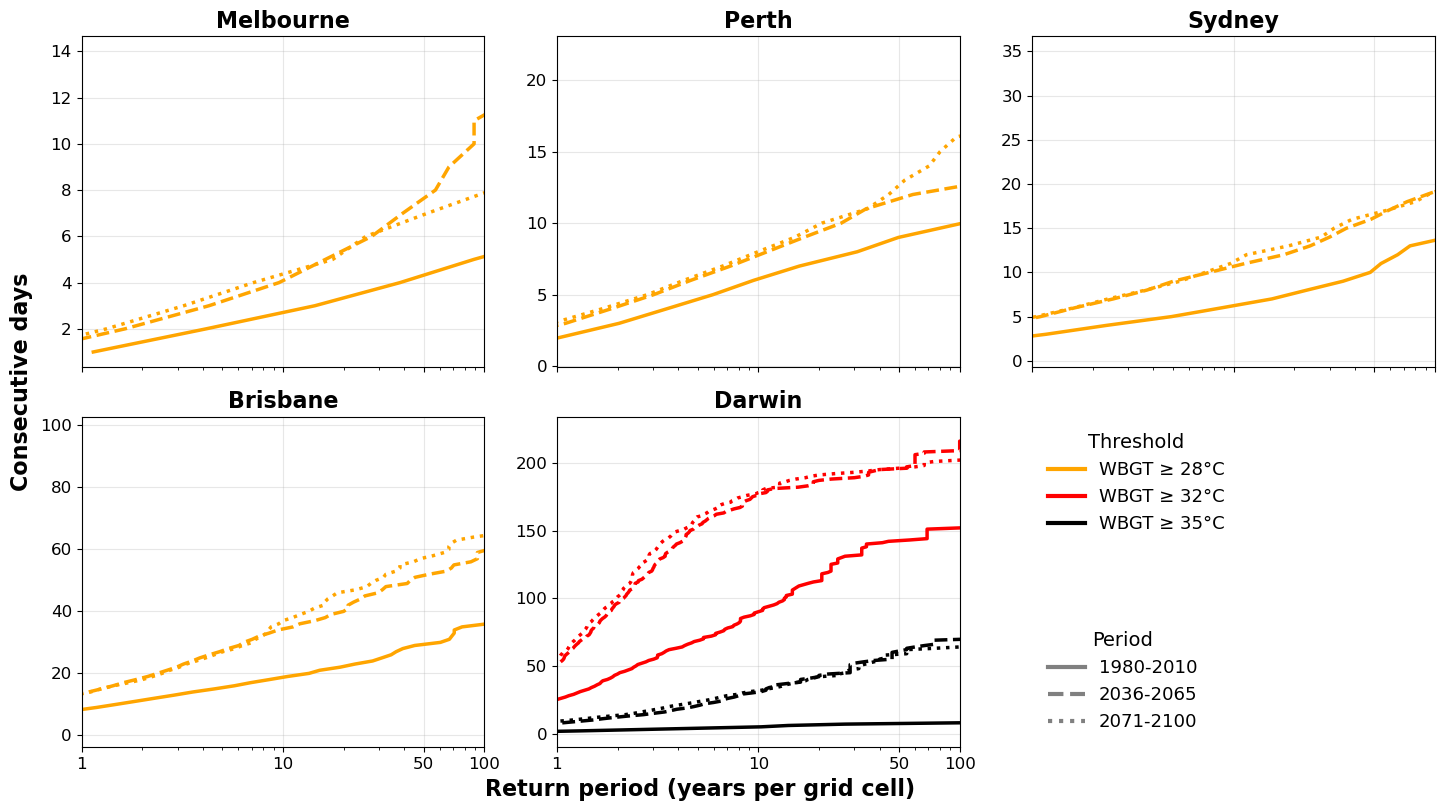

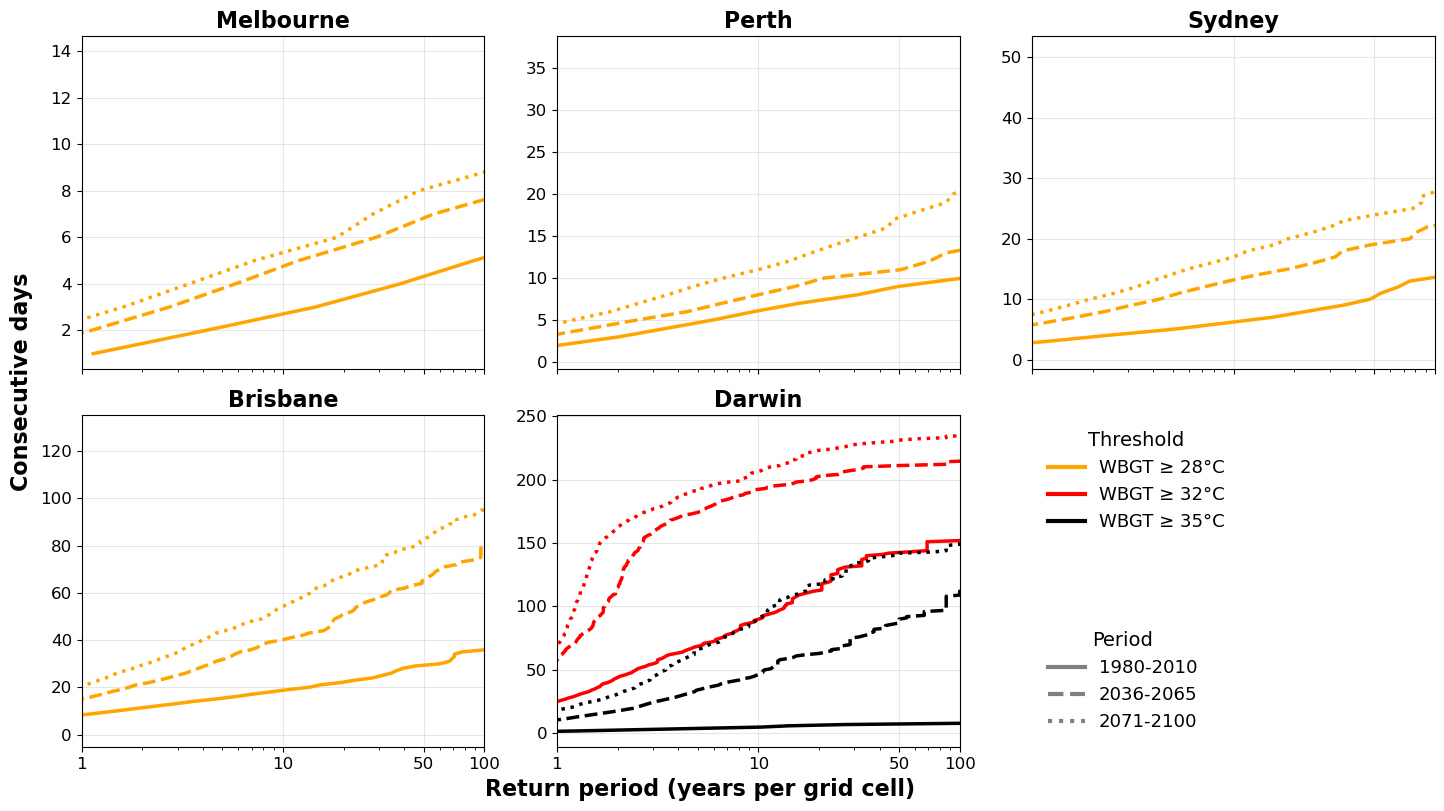

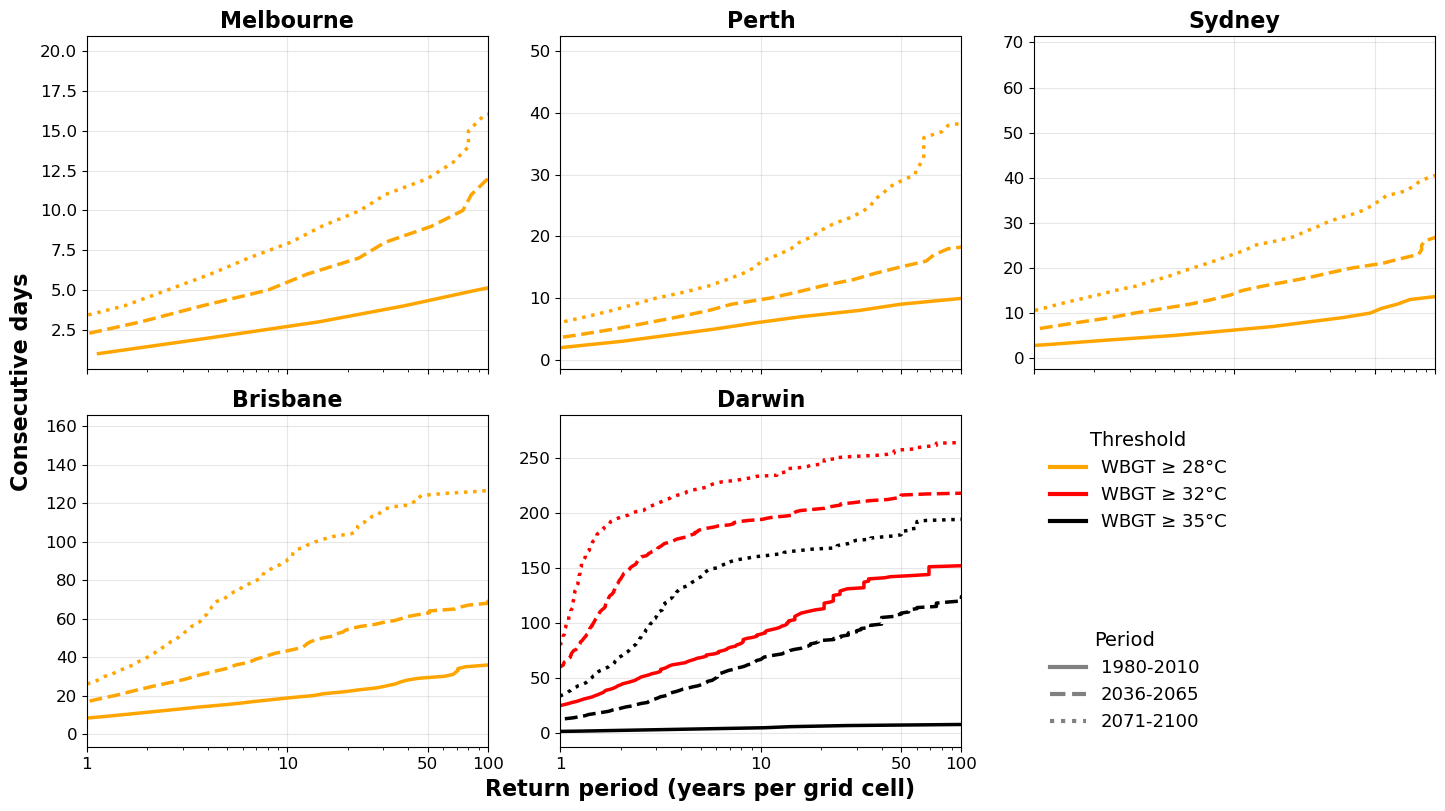

In [4]:
ds = xr.open_dataset(
    "/scratch/dt6/xw9650/tmp/city_subsets_consecutive/wbgt_combined_consecutive_runs.nc"
)

cities = [
    "Melbourne",
    "Perth",
    "Sydney",
    "Brisbane",
    "Darwin"
]

df_rp = plot_wbgt_return_periods_duration(
    ds=ds,
    cities=cities
)

In [6]:
#(superseded)
import os
import re
import glob
import xarray as xr
import numpy as np
import dask

data_dir = "/scratch/dt6/xw9650/tmp/city_subsets_consecutive/"
scenarios = ["ssp126", "ssp245", "ssp370"]
thresholds = ["28", "32", "35"]

# ------------------------------------------
# FILE PARSER FOR METADATA
# ------------------------------------------

def parse_filename(fname):
    """
    Expected pattern example:
    wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_28_consecutive_run.nc
    
    Extracted:
      gcm = ACCESS-ESM1-5
      rcm = NARCliM2-0-WRF412R3
      scenario = ssp370
      threshold = 28
    """
    base = os.path.basename(fname)
    m = re.match(
        r"wbgt_(.+?)_(NARCliM2-0-.+?)_(historical|ssp\d+)_(\d+)_consecutive_run.nc",
        base
    )
    if not m:
        raise ValueError(f"Filename format not recognized: {base}")
    
    gcm = m.group(1)
    rcm = m.group(2)
    scenario = m.group(3)
    threshold = m.group(4)
    return gcm, rcm, scenario, threshold


# ------------------------------------------
# LOAD AND COMBINE ALL FILES
# ------------------------------------------

def load_and_combine(data_dir):
    pattern = os.path.join(data_dir, "wbgt_*_consecutive_run.nc")
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} files")
    
    datasets = []
    
    for f in files:
        gcm, rcm, scenario, threshold = parse_filename(f)
        ensemble = f"{gcm}_{rcm}"
        
        print(f"Loading: {os.path.basename(f)} → {ensemble}, {scenario}, thr={threshold}")
        
        ds = xr.open_dataset(f, use_cftime=True)
        
        # Add metadata as coordinates (scalar coords for this file)
        ds = ds.assign_coords({
            'gcm': gcm,
            'rcm': rcm,
            'scenario': scenario,
            'threshold': threshold,
            'ensemble': ensemble
        })
        
        # Expand dims so they become dimensions for concat
        ds_expanded = ds.expand_dims({
            'ensemble': [ensemble],
            'scenario': [scenario],
            'threshold': [threshold]
        })
        
        datasets.append(ds_expanded)
    
    print("Combining datasets ...")
    combined = xr.combine_by_coords(datasets)
    
    return combined


# ------------------------------------------
# EXECUTE LOAD
# ------------------------------------------

with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ds_combined = load_and_combine(data_dir)


# ------------------------------------------
# OPTIONAL: SAVE OUTPUT
# ------------------------------------------

output_file = "/scratch/dt6/xw9650/tmp/city_subsets_consecutive/wbgt_combined_runs.nc"
ds_combined.to_netcdf(output_file)
print(f"Combined dataset saved to: {output_file}")


Found 120 files
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_historical_28_consecutive_run.nc → ACCESS-ESM1-5_NARCliM2-0-WRF412R3, historical, thr=28
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_historical_32_consecutive_run.nc → ACCESS-ESM1-5_NARCliM2-0-WRF412R3, historical, thr=32
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_historical_35_consecutive_run.nc → ACCESS-ESM1-5_NARCliM2-0-WRF412R3, historical, thr=35
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp126_28_consecutive_run.nc → ACCESS-ESM1-5_NARCliM2-0-WRF412R3, ssp126, thr=28
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp126_32_consecutive_run.nc → ACCESS-ESM1-5_NARCliM2-0-WRF412R3, ssp126, thr=32
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp126_35_consecutive_run.nc → ACCESS-ESM1-5_NARCliM2-0-WRF412R3, ssp126, thr=35
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_28_consecutive_run.nc → ACCESS-ESM1-5_NARCliM2-0-WRF412R3, ssp245, thr=28
Loading: wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp245_32

TypeError: Cannot combine along dimension 'time' with mixed types. Found: Datetime360Day, Timestamp, DatetimeNoLeap. If importing data directly from a file then setting `use_cftime=True` may fix this issue.